In [23]:
import clevar
import numpy as np
from astropy.table import Table
from clevar.catalog import ClCatalog
from clevar.match_metrics import recovery
import matplotlib.pyplot as plt
from clevar.match import MembershipMatch
from clevar.match_metrics import distances
from clevar.match_metrics import scaling
from clevar.match import ProximityMatch
from clevar.match_metrics.recovery import ClCatalogFuncs as r_cf

In [14]:
import GCRCatalogs
redmapper_cosmodc2_cl = GCRCatalogs.load_catalog("cosmoDC2_v1.1.4_redmapper_v0.8.1")
print(redmapper_cosmodc2_cl.list_all_quantities())
data_redmapper = redmapper_cosmodc2_cl.get_quantities(["ra", "dec", "redshift", "richness"])
redmapper_table = Table(data_redmapper)

wazp_cosmodc2_path = '/sps/lsst/groups/clusters/cl_pipeline_project/pywazp_gaussian_catalogs/010/wazp_clusters.fits'
wazp_cosmodc2_path_filtered = '/sps/lsst/groups/clusters/cl_pipeline_project/pywazp_gaussian_catalogs/010/wazp_clusters_snr10_rich20.fits'
wazp_cosmodc2_cl = Table.read(wazp_cosmodc2_path)
halo_path = "/sps/lsst/groups/clusters/cl_pipeline_project/pywazp_gaussian_catalogs/full_halo_catalog_with_m200c_cut.fits"
halo_catalog = Table.read(halo_path)


def clean_mt_cols(table):
    for col in list(table.colnames):
        if col.startswith("mt_"):
            table.remove_column(col)
    return table
halo_catalog = clean_mt_cols(halo_catalog)

redmapper_cosmodc2_path = "/sps/lsst/groups/clusters/cl_pipeline_project/redmapper_cosmodc2_20rich.fits"

#### CUTS #####
wazp_cosmodc2_cl = wazp_cosmodc2_cl[
    (wazp_cosmodc2_cl["snr"] >= 13.0) & 
    # (wazp_cosmodc2_cl["n200"] >= 20.0) &
    (wazp_cosmodc2_cl["zp"] <= 1.0)]
redmapper_table = redmapper_table[
    (redmapper_table["richness"] >= 20.0) &
    (redmapper_table["redshift"] <= 1.0)
]

redmapper_table.write(redmapper_cosmodc2_path, overwrite=True)
wazp_cosmodc2_cl.write(wazp_cosmodc2_path_filtered, overwrite=True)               
display(wazp_cosmodc2_cl)
display(halo_catalog)
display(redmapper_table)

['maskfrac', 'mag_r_lsst_member', 'p_cen_2', 'p_cen_3', 'id_cen_3', 'mag_i_lsst_member', 'dec_cen_4', 'ra_cen_2', 'magerr_g_lsst_member', 'redshift', 'id_cen_4', 'id_cen_1', 'p_cen_0', 'id_member', 'ra_cen_1', 'ra_cen_4', 'dec_member', 'theta_r_member', 'ra', 'dec_cen_2', 'mag_g_lsst_member', 'richness', 'magerr_y_lsst_member', 'id_cen_0', 'id_cen_2', 'pfree_member', 'p_cen_4', 'p_cen_1', 'mag_y_lsst_member', 'richness_err', 'magerr_r_lsst_member', 'dec', 'redshift_true_cg', 'magerr_i_lsst_member', 'ra_cen_3', 'cluster_id', 'magerr_z_lsst_member', 'cluster_id_member', 'dec_cen_1', 'refmag_err_member', 'p_member', 'scaleval', 'dec_cen_0', 'theta_i_member', 'redshift_err', 'mag_z_lsst_member', 'dec_cen_3', 'ra_cen_0', 'ra_member', 'redshift_true_member', 'refmag_member']


id,ra,dec,zp,snr,r200_mpc,n200,n200_err,n500kpc,n500kpc_err,raw_coverfrac,weighted_coverfrac,bkg_coverfrac,md_bkg_arcmin2,md_bkg_mpc2,slope_dprofile,radius_vec_arcmin,radius_vec_mpc,richness,richness_err,nmem,mstar,flag_pmem
bytes30,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64[15],float64[15],float64[15],float64[15],int64,float32,int64
7193,47.86995951381351,-32.755165693480265,0.77046543,13.119,0.925,36.089,1.75,26.918,1.092,68.9,82.1,35.2,0.88,4.16,-0.616,0.327 .. 6.537,0.15 .. 3.0,3.6231821737964216 .. 45.16991308258603,0.20937711024529046 .. 2.455493449130573,81,21.24269,0
5067,47.90353753695014,-38.74192291745326,0.60954577,14.392,0.824,23.927,2.128,18.388,1.035,80.0,90.4,40.8,0.71,4.08,-1.42,0.359 .. 7.184,0.15 .. 3.0,8.546808838520024 .. 33.39099857651623,0.6387399474845994 .. 4.099803607764672,70,20.64382,0
4371,47.92798390835343,-27.285952745052366,0.86121947,14.977,0.941,39.357,2.473,25.732,0.973,100.0,100.0,41.1,0.97,4.29,-1.469,0.315 .. 6.303,0.15 .. 3.0,13.498466451910502 .. 52.873807517854736,0.42952142022610124 .. 4.3427119704173895,116,21.576532,0
3527,47.958502904852445,-38.772926979094095,0.5872425,15.892,0.738,14.855,2.194,11.048,1.323,98.2,99.2,45.1,0.74,4.42,-1.28,0.365 .. 7.308,0.15 .. 3.0,2.962296201318866 .. 20.559475787110962,0.6231794278833954 .. 3.410632216904217,47,20.52695,0
4702,48.0051364201969,-27.13481060759936,0.69802916,14.693,1.025,38.573,2.319,21.627,1.192,80.4,91.6,49.7,0.75,3.82,-1.124,0.339 .. 6.783,0.15 .. 3.0,7.14745767240936 .. 44.07918812189877,0.4377174711621381 .. 2.8200244218277475,80,21.007298,0
5832,48.06768314419819,-29.967078611332003,0.7894888,13.86,0.697,15.493,2.301,12.824,1.618,100.0,100.0,72.6,1.19,5.58,-1.659,0.324 .. 6.482,0.15 .. 3.0,9.272373889652107 .. 19.797209329575107,0.2713282374810731 .. 3.7687822273882774,57,21.303564,0
6423,48.116562506674626,-41.67208147185484,0.54604834,13.521,0.754,18.834,1.101,15.863,0.687,100.0,100.0,66.3,0.64,4.09,-1.265,0.378 .. 7.569,0.15 .. 3.0,4.9718274762420105 .. 26.49045899683592,0.19814912281943836 .. 2.9356847409260554,61,20.311193,0
6922,48.15152636185675,-30.30045320783226,0.7957192,13.24,0.905,32.991,1.888,18.55,1.286,90.7,96.3,53.7,0.93,4.31,-0.839,0.323 .. 6.464,0.15 .. 3.0,4.599718663946542 .. 46.99834970311754,0.18075798475105057 .. 2.5607532040486407,88,21.324589,0
4781,48.15587222299769,-35.59505087788674,0.80648124,14.621,0.871,34.091,2.333,22.798,1.332,100.0,100.0,82.9,1.23,5.65,-1.013,0.322 .. 6.435,0.15 .. 3.0,6.406884985010174 .. 41.475328516751624,0.7020046906322606 .. 3.060090750286108,104,21.364246,0


ra_true,dec_true,redshift_true,NMEM_z_star2,r200c,halo_id,halo_mass,m200c
float64,float64,float64,int64,float64,int64,float64,float64
50.957678900761394,-41.3448059771583,0.04803776741027832,13,0.8275436683439873,7300151475,7.462e+13,63046332035245.07
49.50377592935664,-40.240490667975706,0.11421597003936768,12,0.860030214551469,43700151442,6.921e+13,60807967862264.79
51.06907727982047,-39.64607328475867,0.1259174346923828,16,0.850044589647105,52300151442,6.297e+13,58720563188461.98
50.52541974335929,-39.759854374325954,0.16475677490234375,16,0.9219506257016894,70700151421,1.2e+14,68254428849397.19
50.54038986767568,-39.0704158967892,0.21005773544311523,31,1.1322081089019775,78600151411,1.486e+14,120390041092326.77
50.170338564932,-39.51566808485035,0.2076319456100464,59,1.3884588866166667,95400151411,2.283e+14,222022091351977.47
50.64208660915858,-41.40265859512897,0.19159162044525146,84,1.4041833474602499,130200151411,2.639e+14,229655937300912.7
51.19489753953479,-40.87828426780436,0.18677890300750732,24,1.119497880129747,191900151411,1.279e+14,116379211308709.86
50.13040773558871,-41.24880382828121,0.19323325157165527,13,0.8890673308305338,253900151411,7.091e+13,58288508524169.016


richness,redshift,ra,dec
float32,float32,float64,float64
190.70665,0.5135129,52.520436430812914,-25.717996124671657
179.12813,0.5712697,56.920376528125075,-27.20434071042304
167.33603,0.63518524,58.56362402841767,-27.429961828331713
111.9147,0.44230303,58.35519782866568,-26.867687128773035
104.439766,0.46697217,57.76575707007693,-28.119101936484828
103.49396,0.4413634,58.509466974185045,-26.989676182075844
89.59668,0.56753683,52.67840938259691,-25.63184326314064
77.40795,0.5004612,55.921967922754376,-28.132262944443035
82.35056,0.4993054,55.75070083388977,-28.927070831301904


In [15]:
cl_redmapper_tags = {'mass':'richness', 'z':'redshift', 'ra':'ra','dec':'dec'}
cl_wazp_tags = {'mass':'n200', 'z':'zp','ra':'ra','dec':'dec', 'snr':'snr'}
halo_tags = {'id':'halo_id', 'mass':'m200c', 'z':'redshift_true', 'ra':'ra_true','dec':'dec_true'}


In [16]:
cat_red = ClCatalog(data = redmapper_table,tags=cl_redmapper_tags, name='cat_red')
cat_wazp = ClCatalog(data = wazp_cosmodc2_cl,tags=cl_wazp_tags, name='cat_wazp')
cat_halo = ClCatalog(data = halo_catalog,tags=halo_tags, name='cat_halo')

/sps/lsst/users/ebarroso/conda_envs/firecrown_clp/lib/python3.13/site-packages/clevar/catalog/tagdata.py:308: UserWarning: id column missing, additional one is being created.
  warnings.warn(f"{id_name} column missing, additional one is being created.")


In [17]:
display(cat_halo)

halo_id (id),m200c (mass),redshift_true (z),ra_true (ra),dec_true (dec),NMEM_z_star2,r200c,halo_mass
str21,float64,float64,float64,float64,int64,float64,float64
7300151475,63046332035245.07,0.04803776741027832,50.957678900761394,-41.3448059771583,13,0.8275436683439873,7.462e+13
43700151442,60807967862264.79,0.11421597003936768,49.50377592935664,-40.240490667975706,12,0.860030214551469,6.921e+13
52300151442,58720563188461.98,0.1259174346923828,51.06907727982047,-39.64607328475867,16,0.850044589647105,6.297e+13
70700151421,68254428849397.19,0.16475677490234375,50.52541974335929,-39.759854374325954,16,0.9219506257016894,1.2e+14
78600151411,120390041092326.77,0.21005773544311523,50.54038986767568,-39.0704158967892,31,1.1322081089019775,1.486e+14
95400151411,222022091351977.47,0.2076319456100464,50.170338564932,-39.51566808485035,59,1.3884588866166667,2.283e+14
130200151411,229655937300912.7,0.19159162044525146,50.64208660915858,-41.40265859512897,84,1.4041833474602499,2.639e+14
191900151411,116379211308709.86,0.18677890300750732,51.19489753953479,-40.87828426780436,24,1.119497880129747,1.279e+14
253900151411,58288508524169.016,0.19323325157165527,50.13040773558871,-41.24880382828121,13,0.8890673308305338,7.091e+13


In [18]:
from astropy.cosmology import FlatLambdaCDM
from clevar.cosmology import AstroPyCosmology
from clevar.match import output_matched_catalog

cosmo_astropy = FlatLambdaCDM(
    H0=71.0,
    Om0=0.2648,
    Ob0=0.0448
)

cosmo = AstroPyCosmology()
cosmo._init_from_cosmo(be_cosmo=cosmo_astropy)
mt = ProximityMatch()
match_config = {
    'type': 'cross', # options are cross, cat1, cat2
    'which_radius': 'max', # Case of radius to be used, can be: cat1, cat2, min, max
    'preference': 'more_massive', # options are more_massive, angular_proximity or redshift_proximity
    'catalog1': {'delta_z':.2,
                'match_radius': '1 mpc'
                },
    'catalog2': {'delta_z':.2,
                'match_radius': '1 mpc'
                }
}
#### Match Redmapper to Wazp #####
mt.match_from_config(cat_red, cat_wazp, match_config, cosmo=cosmo)


output_matched_catalog(
    redmapper_cosmodc2_path,
    wazp_cosmodc2_path_filtered,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_redmapper_matched.fits",
    cat_red, 
    cat_wazp,
    overwrite=True)

#### Match Redmapper to Halos #####
cat_red = ClCatalog(data = redmapper_table,tags=cl_redmapper_tags, name='cat_red')
cat_wazp = ClCatalog(data = wazp_cosmodc2_cl,tags=cl_wazp_tags, name='cat_wazp')
cat_halo = ClCatalog(data = halo_catalog,tags=halo_tags, name='cat_halo')
mt.match_from_config(cat_red, cat_halo, match_config, cosmo=cosmo)
output_matched_catalog(
    redmapper_cosmodc2_path,
    halo_path,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/redmapper_20rich_halo_matched.fits",
    cat_red, 
    cat_halo,
    overwrite=True)

#### Match Wazp to Halos #####
cat_red = ClCatalog(data = redmapper_table,tags=cl_redmapper_tags, name='cat_red')
cat_wazp = ClCatalog(data = wazp_cosmodc2_cl,tags=cl_wazp_tags, name='cat_wazp')
cat_halo = ClCatalog(data = halo_catalog,tags=halo_tags, name='cat_halo')
mt.match_from_config(cat_wazp, cat_halo, match_config, cosmo=cosmo)
output_matched_catalog(
    wazp_cosmodc2_path_filtered,
    halo_path,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_10snr_20rich_halo_matched.fits",
    cat_wazp, 
    cat_halo,
    overwrite=True)


## ClCatalog 1
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## ClCatalog 2
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## Multiple match (catalog 1)
Finding candidates (cat_red)
* 2,821/3,735 objects matched.

## Multiple match (catalog 2)
Finding candidates (cat_wazp)
* 2,894/4,531 objects matched.

## Finding unique matches of catalog 1
Unique Matches (cat_red)
* 2,770/3,735 objects matched.

## Finding unique matches of catalog 2
Unique Matches (cat_wazp)
* 2,770/4,531 objects matched.
Cross Matches (cat_red)
* 2,770/3,735 objects matched.
Cross Matches (cat_wazp)
* 2,770/4,531 objects matched.

## ClCatalog 1
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## ClCatalog 2
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## Multiple matc

In [36]:
matched_wazp_red = Table.read("/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_redmapper_matched.fits")
matched_wazp_halo = Table.read("/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_10snr_20rich_halo_matched.fits")
matched_red_halo = Table.read("/sps/lsst/groups/clusters/cl_pipeline_project/redmapper_20rich_halo_matched.fits")

matched_wazp_halo ["mt_cross"] = matched_wazp_halo['cat2_mt_cross']
matched_wazp_halo ['cat2_log_m200c'] = np.log10(matched_wazp_halo['cat2_m200c'])

matched_red_halo ["mt_cross"] = matched_red_halo['cat2_mt_cross']
matched_red_halo ['cat2_log_m200c'] = np.log10(matched_red_halo['cat2_m200c'])

cat_wazp_halo = ClCatalog(data = matched_wazp_halo, name='cat_wazp')
cat_red_halo = ClCatalog(data = matched_red_halo, name='cat_red')


/tmp/ipykernel_4520/1291590102.py:6: RuntimeWarning: invalid value encountered in log10
  matched_wazp_halo ['cat2_log_m200c'] = np.log10(matched_wazp_halo['cat2_m200c'])


5060
4320
8381
5327
4996
9009
23194
2495
2747
2217
4538


cat1_id,cat1_ra,cat1_dec,cat1_zp,cat1_snr,cat1_r200_mpc,cat1_n200,cat1_n200_err,cat1_n500kpc,cat1_n500kpc_err,cat1_raw_coverfrac,cat1_weighted_coverfrac,cat1_bkg_coverfrac,cat1_md_bkg_arcmin2,cat1_md_bkg_mpc2,cat1_slope_dprofile,cat1_radius_vec_arcmin,cat1_radius_vec_mpc,cat1_richness,cat1_richness_err,cat1_nmem,cat1_mstar,cat1_flag_pmem,cat2_ra_true,cat2_dec_true,cat2_redshift_true,cat2_NMEM_z_star2,cat2_r200c,cat2_halo_id,cat2_halo_mass,cat2_mt_self,cat2_mt_other,cat2_mt_multi_self,cat2_mt_multi_other,cat2_mt_frac_other,cat2_mt_frac_self,cat2_mt_cross,cat2_mt_all,cat2_m200c,mt_cross,cat2_log_m200c
bytes30,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64[15],float64[15],float64[15],float64[15],int64,float32,int64,float64,float64,float64,int64,float64,int64,float64,bytes6,bytes6,bytes162,bytes162,float64,float64,bytes6,bool,float64,bytes6,float64
7193,47.86995951381351,-32.755165693480265,0.77046543,13.119,0.925,36.089,1.75,26.918,1.092,68.9,82.1,35.2,0.88,4.16,-0.616,0.327 .. 6.537,0.15 .. 3.0,3.6231821737964216 .. 45.16991308258603,0.20937711024529046 .. 2.455493449130573,81,21.24269,0,47.88537796639779,-32.75693032745011,0.7709457874298096,37,1.1120182527622706,1124700077279,9.758e+13,5060,5060,5060,5060,0.45716275400367506,0.33620689655172414,5060,True,65323732772777.47,5060,13.815070993521779
5067,47.90353753695014,-38.74192291745326,0.60954577,14.392,0.824,23.927,2.128,18.388,1.035,80.0,90.4,40.8,0.71,4.08,-1.42,0.359 .. 7.184,0.15 .. 3.0,8.546808838520024 .. 33.39099857651623,0.6387399474845994 .. 4.099803607764672,70,20.64382,0,47.9017423870058,-38.739471097195235,0.6072328090667725,24,1.118043190996412,385900137307,7.657e+13,4320,4320,"4320,5327","4320,5327",0.3597634900549957,0.41379310344827586,4320,True,74019511512338.03,4320,13.869346214666198
4371,47.92798390835343,-27.285952745052366,0.86121947,14.977,0.941,39.357,2.473,25.732,0.973,100.0,100.0,41.1,0.97,4.29,-1.469,0.315 .. 6.303,0.15 .. 3.0,13.498466451910502 .. 52.873807517854736,0.42952142022610124 .. 4.3427119704173895,116,21.576532,0,47.92749368911468,-27.28747765640985,0.8512330055236816,30,1.2065141133859125,1021000029266,8.567e+13,8381,8381,"36310,8381,73605","36310,73605,8381",0.3391943014538048,0.38235294117647056,8381,True,79435823029002.83,8381,13.90001639959674
3527,47.958502904852445,-38.772926979094095,0.5872425,15.892,0.738,14.855,2.194,11.048,1.323,98.2,99.2,45.1,0.74,4.42,-1.28,0.365 .. 7.308,0.15 .. 3.0,2.962296201318866 .. 20.559475787110962,0.6231794278833954 .. 3.410632216904217,47,20.52695,0,47.95738163826518,-38.769445029940925,0.6025955677032471,12,0.9541915336125334,958300137307,5.655e+13,5327,5327,"4320,63326,17942,5327","4320,5327,17942,63326",0.136687757067674,0.3055555555555556,5327,True,46008750183842.26,5327,13.66284043592437
4702,48.0051364201969,-27.13481060759936,0.69802916,14.693,1.025,38.573,2.319,21.627,1.192,80.4,91.6,49.7,0.75,3.82,-1.124,0.339 .. 6.783,0.15 .. 3.0,7.14745767240936 .. 44.07918812189877,0.4377174711621381 .. 2.8200244218277475,80,21.007298,0,48.006735602909714,-27.13436188066558,0.6930584907531738,51,1.5906589131959727,1144000029293,1.894e+14,4996,4996,4996,4996,0.21176491966181912,0.08955223880597014,4996,True,201272999428326.78,4996,14.303785518625467
5832,48.06768314419819,-29.967078611332003,0.7894888,13.86,0.697,15.493,2.301,12.824,1.618,100.0,100.0,72.6,1.19,5.58,-1.659,0.324 .. 6.482,0.15 .. 3.0,9.272373889652107 .. 19.797209329575107,0.2713282374810731 .. 3.7687822273882774,57,21.303564,0,48.06677195501344,-29.967938477849998,0.7950392961502075,10,0.8312367217641482,1872700051272,2.98e+13,9009,9009,"50603,9009","50603,9009",0.16685871591165558,0.3793103448275862,9009,True,26607878882433.805,9009,13.42501025499592
6423,48.116562506674626,-41.67208147185484,0.54604834,13.521,0.754,18.834,1.101,15.863,0.687,100.0,100.0,66.3,0.64,4.09,-1.265,0.378 .. 7.569,0.15 .. 3.0,4.9718274762420105 .. 26.49045899683592,0.198149122819438

cat1_richness,cat1_redshift,cat1_ra,cat1_dec,cat2_ra_true,cat2_dec_true,cat2_redshift_true,cat2_NMEM_z_star2,cat2_r200c,cat2_halo_id,cat2_halo_mass,cat2_mt_self,cat2_mt_other,cat2_mt_multi_self,cat2_mt_multi_other,cat2_mt_frac_other,cat2_mt_frac_self,cat2_mt_cross,cat2_mt_all,cat2_m200c,mt_cross,cat2_log_m200c
float32,float32,float64,float64,float64,float64,float64,int64,float64,int64,float64,bytes6,bytes6,bytes162,bytes162,float64,float64,bytes6,bool,float64,bytes6,float64
190.70665,0.5135129,52.520436430812914,-25.717996124671657,52.51195711178284,-25.715205898233762,0.5133163928985596,117,1.7948521694666904,1162500021323,5.462e+14,60,60,"158192,106994,176688,41029,28197,60,13690","158192,106994,176688,41029,28197,60,13690",0.2904289293204089,0.3542319749216301,60,True,326491145207346.5,60,14.513871407235179
179.12813,0.5712697,56.920376528125075,-27.20434071042304,56.91642067641457,-27.20102444969963,0.5722380876541138,257,2.2773205394476235,549500032315,1.01e+15,12,12,"12,11472","12,11472",0.4983808864613906,0.45083487940630795,12,True,645749230889104.2,12,14.810063897585088
167.33603,0.63518524,58.56362402841767,-27.429961828331713,58.56499589336182,-27.428517577714587,0.6424993276596069,258,1.6148221324866927,1275900032300,3.885e+14,18,18,"143013,55454,6544,18","143013,55454,6544,18",0.5769434403015512,0.3645833333333333,18,True,216337687012597.2,18,14.335132182110852
111.9147,0.44230303,58.35519782866568,-26.867687128773035,58.350156087223354,-26.868354329706165,0.4414263963699341,93,1.7306878533161862,564000032338,3.569e+14,143,143,"17514,88299,143","17514,88299,143",0.4005503152655266,0.337037037037037,143,True,322972230485814.1,143,14.509165182810255
104.439766,0.46697217,57.76575707007693,-28.119101936484828,57.76248728189184,-28.116127659148276,0.47020912170410156,163,1.6463445945524835,459400032338,3.582e+14,51,51,"51,130056,7713,24377","51,130056,7713,24377",0.607360684264902,0.3877551020408163,51,True,278007164916462.0,51,14.44405598888061
103.49396,0.4413634,58.509466974185045,-26.989676182075844,58.50959198022092,-26.991315153185255,0.4413374662399292,159,1.8478873749853861,156700032338,4.369e+14,308,308,"143,308,91621,83848,159523,84528,88299","143,308,91621,83848,159523,84528,88299",0.4562750145264784,0.34834123222748814,308,True,393139675482140.9,308,14.59454687483883
89.59668,0.56753683,52.67840938259691,-25.63184326314064,52.66999315010954,-25.629171388025185,0.5709124803543091,123,2.0029014265033562,1563900021315,4.474e+14,199,199,"43672,165615,4388,199,160387,41029,88568,60,67652,9966","43672,165615,4388,199,160387,41029,88568,60,67652,9966",0.5236992000291308,0.3507246376811594,199,True,439309794128045.06,199,14.64277088568815
77.40795,0.5004612,55.921967922754376,-28.132262944443035,55.91322860227157,-28.127397566306087,0.5015562772750854,85,1.7266775520754534,310600042331,3.358e+14,461,461,"43803,49445,130143,461","130143,49445,461,43803",0.39023773189142685,0.37333333333333335,461,True,299131074023481.7,461,14.475861530302977
82.35056,0.4993054,55.75070083388977,-28.927070831301904,55.741238168463696,-28.921494646768707,0.5001400709152222,91,1.978064087075247,1265300042331,5.667e+14,862,862,"19158,66190,1175,862","66190,1175,19158,862",0.29582097505959215,0.3384615384615385,862,True,449733785617307.06,862,14.652955514554844


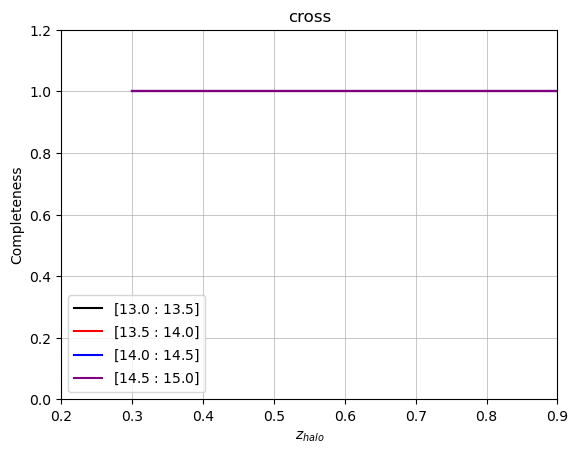

{'recovery': array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]]), 'edges1': array([0.3 , 0.45, 0.65, 0.8 , 1.  ]), 'edges2': array([13. , 13.5, 14. , 14.5, 15. ]), 'matched': array([[  6, 229, 354,  53],
       [ 12, 336, 581,  84],
       [ 11, 409, 496,  63],
       [ 43, 631, 619,  52]]), 'counts': array([[  6, 229, 354,  53],
       [ 12, 336, 581,  84],
       [ 11, 409, 496,  63],
       [ 43, 631, 619,  52]])}


In [37]:
halo_redshift_col = 'cat2_redshift_true' 
mass_col = 'cat2_log_m200c'

display(matched_wazp_halo['mt_cross'])
display(matched_wazp_halo)
display(matched_red_halo)


figx=10
figy=7
matching_selected = 'cross'
zbins = np.array([0.3,  0.45, 0.65, 0.8,  1.])
mbins = np.array([13., 13.5, 14., 14.5, 15.])
fig = plt.figure()#figsize=(figx,figy))
info_comp = r_cf.plot(cat_wazp_halo, col1=halo_redshift_col, col2=mass_col, bins1=zbins, bins2=mbins, matching_type=matching_selected, legend_format=lambda x: x, lines_kwargs_list = [{'color':'black'}, {'color':'red'}, {'color':'blue'}, {'color':'purple'}, {'color':'orange'}])
info_comp['ax'].set_xlabel('$z_{halo}$')
info_comp['ax'].set_ylabel('Completeness') 
info_comp['ax'].set_ylim(0,1.2)
info_comp['ax'].set_xlim(0.2,0.9) 
info_comp['ax'].set_title(f'{matching_selected}')
plt.show(fig)
# plt.savefig(outpath+'recovery_plot.png', bbox_inches='tight')
plt.close(fig)
print(info_comp['data'])



from astropy.cosmology import FlatLambdaCDM
from clevar.cosmology import AstroPyCosmology
from clevar.match import output_matched_catalog

cosmo_astropy = FlatLambdaCDM(
    H0=71.0,
    Om0=0.2648,
    Ob0=0.0448
)

cosmo = AstroPyCosmology()
cosmo._init_from_cosmo(be_cosmo=cosmo_astropy)
mt = ProximityMatch()
match_config = {
    'type': 'cross', # options are cross, cat1, cat2
    'which_radius': 'max', # Case of radius to be used, can be: cat1, cat2, min, max
    'preference': 'more_massive', # options are more_massive, angular_proximity or redshift_proximity
    'catalog1': {'delta_z':.2,
                'match_radius': '1 mpc'
                },
    'catalog2': {'delta_z':.2,
                'match_radius': '1 mpc'
                }
}
#### Match Redmapper to Wazp #####
mt.match_from_config(cat_red, cat_wazp, match_config, cosmo=cosmo)


output_matched_catalog(
    redmapper_cosmodc2_path,
    wazp_cosmodc2_path_filtered,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_redmapper_matched.fits",
    cat_red, 
    cat_wazp,
    overwrite=True)

#### Match Redmapper to Halos #####
cat_red = ClCatalog(data = redmapper_table,tags=cl_redmapper_tags, name='cat_red')
cat_wazp = ClCatalog(data = wazp_cosmodc2_cl,tags=cl_wazp_tags, name='cat_wazp')
cat_halo = ClCatalog(data = halo_catalog,tags=halo_tags, name='cat_halo')
mt.match_from_config(cat_red, cat_halo, match_config, cosmo=cosmo)
output_matched_catalog(
    redmapper_cosmodc2_path,
    halo_path,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/redmapper_20rich_halo_matched.fits",
    cat_red, 
    cat_halo,
    overwrite=True)

#### Match Wazp to Halos #####
cat_red = ClCatalog(data = redmapper_table,tags=cl_redmapper_tags, name='cat_red')
cat_wazp = ClCatalog(data = wazp_cosmodc2_cl,tags=cl_wazp_tags, name='cat_wazp')
cat_halo = ClCatalog(data = halo_catalog,tags=halo_tags, name='cat_halo')
mt.match_from_config(cat_wazp, cat_halo, match_config, cosmo=cosmo)
output_matched_catalog(
    wazp_cosmodc2_path_filtered,
    halo_path,  
    "/sps/lsst/groups/clusters/cl_pipeline_project/wazp_01zp_10snr_20rich_halo_matched.fits",
    cat_wazp, 
    cat_halo,
    overwrite=True)




In [90]:
import copy
def compute_cp_for_snr(
    snr_min,
    snr_max,
    zbins,
    mbins,
    rbins,
    cluster_redshift_col='zp',
    richness_col='n200',
    halo_redshift_col="redshift_true",
    mass_col="log_m200c",
    matching_type="cross"
):

    ### Cosmology ###
    cosmo_astropy = FlatLambdaCDM(
        H0=71.0,
        Om0=0.2648,
        Ob0=0.0448
    )

    cosmo = AstroPyCosmology()
    cosmo._init_from_cosmo(be_cosmo=cosmo_astropy)

    ### Matching config ###
    match_config = {
        'type': 'cross',
        'which_radius': 'max',
        'preference': 'more_massive',
        'catalog1': {'delta_z': .2, 'match_radius': '1 mpc'},
        'catalog2': {'delta_z': .2, 'match_radius': '1 mpc'}
    }

    ### Load catalogs ###
    cat_wazp = ClCatalog(data=wazp_cosmodc2_cl, tags=cl_wazp_tags, name='cat_wazp')
    cat_halo = ClCatalog(data=halo_catalog, tags=halo_tags, name='cat_halo')

    cat_halo['log_m200c'] = np.log10(cat_halo['m200c'])

    # Initial SNR cut
    cat_wazp = cat_wazp[cat_wazp['snr'] >= snr_min]

    ### Matching ###
    mt = ProximityMatch()
    mt.match_from_config(cat_wazp, cat_halo, match_config, cosmo=cosmo)

    # --------------------------------------------------
    # Build SNR lookup
    # --------------------------------------------------
    wazp_ids = cat_wazp["id"]
    wazp_snr = cat_wazp["snr"]
    snr_map = dict(zip(wazp_ids, wazp_snr))

    mt_cross = cat_halo["mt_cross"]

    matched_snr = np.array([
        snr_map.get(mt_id, np.nan) if mt_id is not None else np.nan
        for mt_id in mt_cross
    ])

    comp_list = []
    pur_list = []
    snr_list = np.linspace(snr_min, snr_max, 20)

    # --------------------------------------------------
    # Loop over SNR thresholds
    # --------------------------------------------------
    for snr_i in snr_list:

        # IMPORTANT: copy catalog each iteration
        cat_halo_filtered = copy.deepcopy(cat_halo)

        mask = (matched_snr < snr_i) | np.isnan(matched_snr)

        # Apply masking safely
        cat_halo_filtered["mt_cross"][mask] = None

        # Purity side
        cat_wazp_cut = cat_wazp[cat_wazp["snr"] >= snr_i]

        info_comp = r_cf.plot(
            cat_halo_filtered,
            col1=halo_redshift_col,
            col2=mass_col,
            bins1=zbins,
            bins2=mbins,
            matching_type=matching_type
        )

        info_pur = r_cf.plot(
            cat_wazp_cut,
            col1=cluster_redshift_col,
            col2=richness_col,
            bins1=zbins,
            bins2=rbins,
            matching_type=matching_type
        )

        comp_list.append(info_comp)
        pur_list.append(info_pur)

    return comp_list, pur_list, snr_list

In [91]:
display(cat_halo)
display(cat_wazp)

/tmp/ipykernel_4520/3092573553.py:38: RuntimeWarning: invalid value encountered in log10
  cat_halo['log_m200c'] = np.log10(cat_halo['m200c'])



## ClCatalog 1
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## ClCatalog 2
## Prep mt_cols
### Prep z_cols
* zmin|zmax from config value
### Prep ang_cols
* ang radius from set scale

## Multiple match (catalog 1)
Finding candidates (cat_wazp)
* 4,518/4,531 objects matched.

## Multiple match (catalog 2)
Finding candidates (cat_halo)
* 9,902/165,033 objects matched.s

## Finding unique matches of catalog 1
Unique Matches (cat_wazp)
* 4,512/4,531 objects matched.

## Finding unique matches of catalog 2
Unique Matches (cat_halo)
* 4,512/165,033 objects matched.
Cross Matches (cat_wazp)
* 4,512/4,531 objects matched.
Cross Matches (cat_halo)
* 4,512/165,033 objects matched.


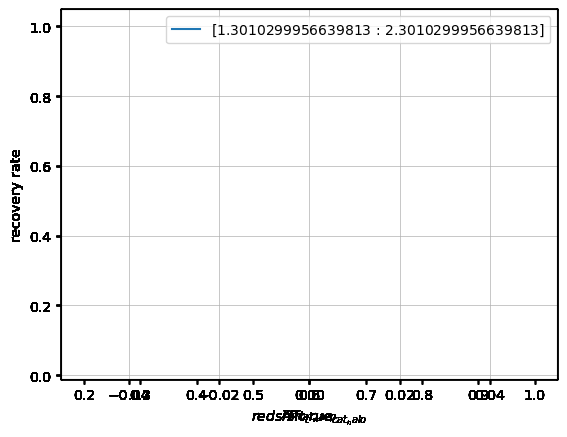

In [94]:


snr_min = 0.0
snr_max = 15.0
list_cp = []
zbins = [0.2, 1.0]
mbins = [13.0, 15.5]
rbins = np.log10([20, 200])
comp_list, pur_list, snr_list = compute_cp_for_snr(snr_min, snr_max, zbins, mbins, rbins)


In [95]:
for i, snr in enumerate(snr_list):
    comp = comp_list[i]
    pur = pur_list[i]
    print(comp)
    print("SNR:", snr)
    print("Completeness:", comp['data']['recovery'])
    print("Purity:", pur['data']['recovery'])

{'data': {'recovery': array([[0.11309287]]), 'edges1': array([0.2, 1. ]), 'edges2': array([13. , 15.5]), 'matched': array([[4261]]), 'counts': array([[37677]])}, 'ax': <Axes: xlabel='$redshift_true_{cat_halo}$', ylabel='recovery rate'>}
SNR: 0.0
Completeness: [[0.11309287]]
Purity: [[nan]]
{'data': {'recovery': array([[0.11309287]]), 'edges1': array([0.2, 1. ]), 'edges2': array([13. , 15.5]), 'matched': array([[4261]]), 'counts': array([[37677]])}, 'ax': <Axes: xlabel='$redshift_true_{cat_halo}$', ylabel='recovery rate'>}
SNR: 0.7894736842105263
Completeness: [[0.11309287]]
Purity: [[nan]]
{'data': {'recovery': array([[0.11309287]]), 'edges1': array([0.2, 1. ]), 'edges2': array([13. , 15.5]), 'matched': array([[4261]]), 'counts': array([[37677]])}, 'ax': <Axes: xlabel='$redshift_true_{cat_halo}$', ylabel='recovery rate'>}
SNR: 1.5789473684210527
Completeness: [[0.11309287]]
Purity: [[nan]]
{'data': {'recovery': array([[0.11309287]]), 'edges1': array([0.2, 1. ]), 'edges2': array([13. , 